# Data Collection and Splitting

In [1]:
import os
import pandas as pd

NFL_YEARS = [str(year) for year in range(2010, 2026)]

DATA_FILEPATH = r"Data"

def load_data(NFL_YEAR):
    path = os.path.join(DATA_FILEPATH, f"{NFL_YEAR}.csv")
    NFL = pd.read_csv(path)
    return NFL

for year in NFL_YEARS:
    df = load_data(year)
    print(f"{year} loaded — {len(df)} teams")

display(df.tail())

2010 loaded — 32 teams
2011 loaded — 32 teams
2012 loaded — 32 teams
2013 loaded — 32 teams
2014 loaded — 32 teams
2015 loaded — 32 teams
2016 loaded — 32 teams
2017 loaded — 32 teams
2018 loaded — 32 teams
2019 loaded — 32 teams
2020 loaded — 32 teams
2021 loaded — 32 teams
2022 loaded — 32 teams
2023 loaded — 32 teams
2024 loaded — 32 teams
2025 loaded — 32 teams


,Tm,W,L,T,W-L%,PF,PA,PD,MoV,SoS,SRS,OSRS,DSRS
27,New Orleans Saints,6,11,0,0.353,306,383,-77,-4.5,-0.3,-4.9,-5.5,0.6
28,Seattle Seahawks,14,3,0,0.824,483,292,191,11.2,1.6,12.8,6.2,6.7
29,Los Angeles Rams,12,5,0,0.706,518,346,172,10.1,2.4,12.5,8.7,3.9
30,San Francisco 49ers,12,5,0,0.706,437,371,66,3.9,2.1,6.0,3.7,2.3
31,Arizona Cardinals,3,14,0,0.176,355,488,-133,-7.8,3.4,-4.4,-1.0,-3.4


In [2]:
# 60/20/20 train/val/test split shared across all models
# Each model imports these globals instead of doing its own split

import os
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split

TEAM = 0; WINS = 1; LOSSES = 2; TIES = 3; WIN_PERCENTAGE = 4
POINTS_FOR = 5; POINTS_AGAINST = 6; POINTS_DIFFERENTIAL = 7
MARGIN_OF_VICTORY = 8; STRENGTH_OF_SCHEDULE = 9
SIMPLE_RATING_SYSTEM = 10; OFFENSIVE_SRS = 11; DEFENSIVE_SRS = 12

NFL_TEAMS = ['Arizona Cardinals', 'Atlanta Falcons', 'Baltimore Ravens', 'Buffalo Bills',
             'Carolina Panthers', 'Chicago Bears', 'Cincinnati Bengals', 'Cleveland Browns',
             'Dallas Cowboys', 'Denver Broncos', 'Detroit Lions', 'Green Bay Packers',
             'Houston Texans', 'Indianapolis Colts', 'Jacksonville Jaguars', 'Kansas City Chiefs',
             'Las Vegas Raiders', 'Los Angeles Chargers', 'Los Angeles Rams', 'Miami Dolphins',
             'Minnesota Vikings', 'New England Patriots', 'New Orleans Saints', 'New York Giants',
             'New York Jets', 'Philadelphia Eagles', 'Pittsburgh Steelers', 'San Francisco 49ers',
             'Seattle Seahawks', 'Tampa Bay Buccaneers', 'Tennessee Titans', 'Washington Commanders']
NFL_YEARS = [str(year) for year in range(2010, 2026)]
DATA_FILEPATH = "Data"
DROP_COLS = ['W', 'L', 'T', 'W-L%', 'PF', 'PA', 'MoV']


def _load_all_years():
    frames = []
    for year in NFL_YEARS:
        path = os.path.join(DATA_FILEPATH, f"{year}.csv")
        raw = pd.read_csv(path)
        raw = raw[raw.iloc[:, TEAM].isin(NFL_TEAMS)].copy()
        raw.columns = ['Team', 'W', 'L', 'T', 'W-L%', 'PF', 'PA', 'PD',
                       'MoV', 'SoS', 'SRS', 'OSRS', 'DSRS']
        raw['Year'] = year
        frames.append(raw)
    combined = pd.concat(frames, ignore_index=True)
    for col in combined.columns:
        if col not in ('Team', 'Year'):
            combined[col] = pd.to_numeric(combined[col], errors='coerce')
    return combined.dropna()


_all_data = _load_all_years()

_features = _all_data[['SoS', 'SRS', 'OSRS', 'DSRS']]
_target = _all_data['W-L%']

# 60% train, 20% val, 20% test
X_train_global, _X_temp, y_train_global, _y_temp = train_test_split(
    _features.values, _target.values,
    test_size=0.40, random_state=42
)
X_val_global, X_test_global, y_val_global, y_test_global = train_test_split(
    _X_temp, _y_temp,
    test_size=0.50, random_state=42
)

print(f"Total samples : {len(_features)}")
print(f"Train (60%)   : {len(X_train_global)}")
print(f"Val   (20%)   : {len(X_val_global)}")
print(f"Test  (20%)   : {len(X_test_global)}")


Total samples : 512
Train (60%)   : 307
Val   (20%)   : 102
Test  (20%)   : 103


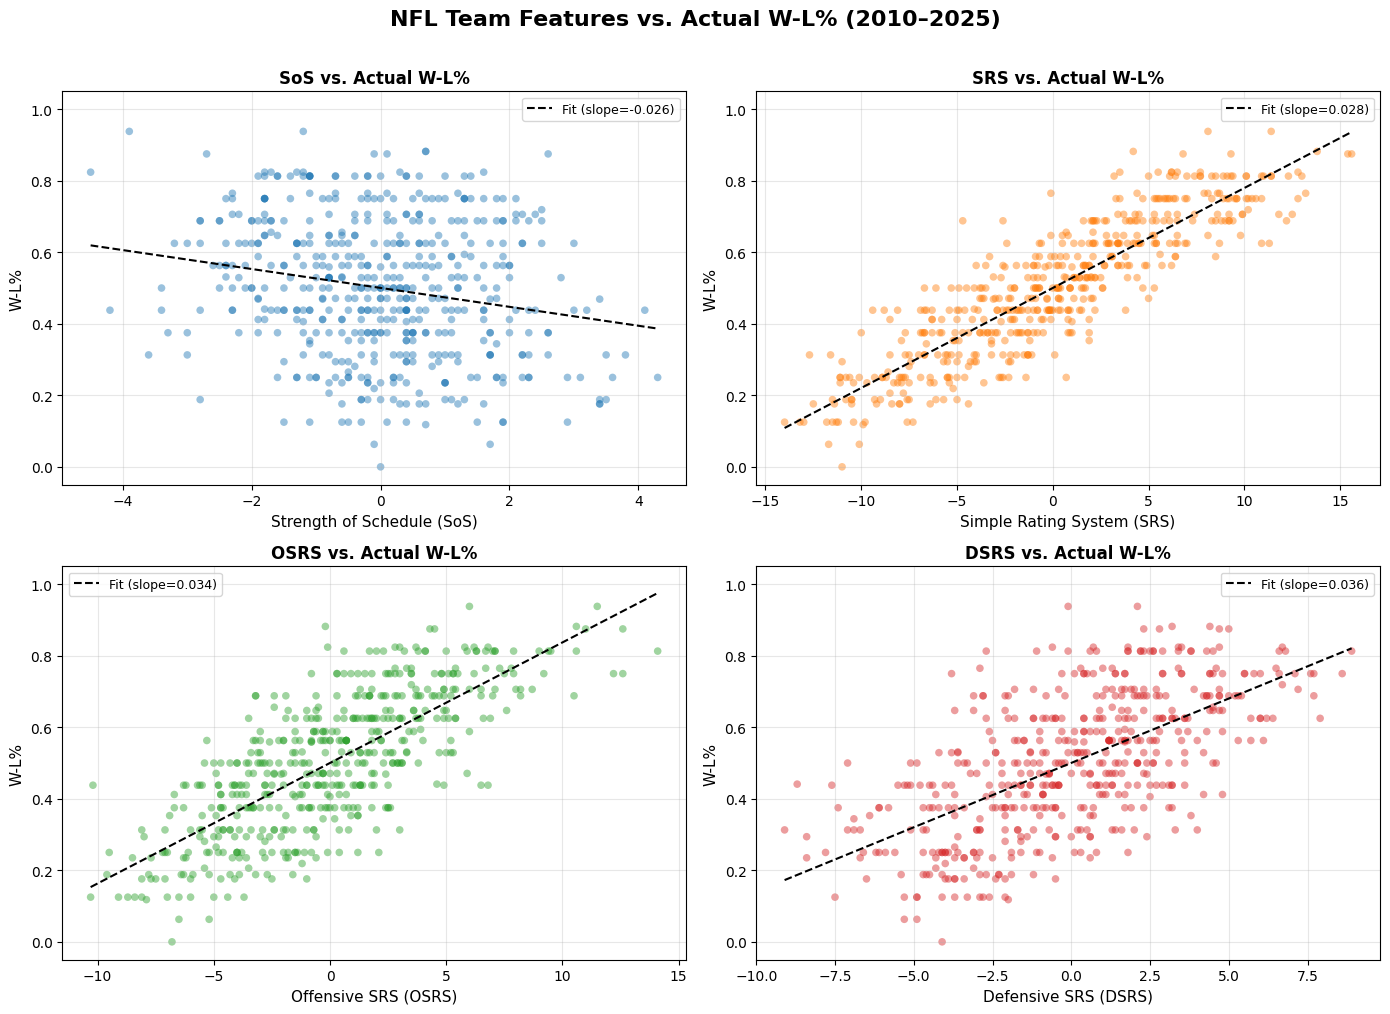

Scatterplot saved as feature_vs_actual_wlpct.png


In [3]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

features = ['SoS', 'SRS', 'OSRS', 'DSRS']
feature_labels = [
    'Strength of Schedule (SoS)',
    'Simple Rating System (SRS)',
    'Offensive SRS (OSRS)',
    'Defensive SRS (DSRS)'
]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('NFL Team Features vs. Actual W-L% (2010–2025)', fontsize=16, fontweight='bold', y=1.01)

for ax, feat, label, color in zip(axes.flat, features, feature_labels, colors):
    x = _all_data[feat].values
    y = _all_data['W-L%'].values
    ax.scatter(x, y, alpha=0.45, s=30, color=color, edgecolors='none')

    # Best-fit line
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle='--', label=f'Fit (slope={m:.3f})')

    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('W-L%', fontsize=11)
    ax.set_title(f'{feat} vs. Actual W-L%', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig('feature_vs_actual_wlpct.png', dpi=150, bbox_inches='tight')
plt.show()
print('Scatterplot saved as feature_vs_actual_wlpct.png')


# Logistic Regression Model

## Greg Yonan

In [4]:
import os
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

# Column indices
TEAM = 0; WINS = 1; LOSSES = 2; TIES = 3; WIN_PERCENTAGE = 4
POINTS_FOR = 5; POINTS_AGAINST = 6; POINTS_DIFFERENTIAL = 7
MARGIN_OF_VICTORY = 8; STRENGTH_OF_SCHEDULE = 9
SIMPLE_RATING_SYSTEM = 10; OFFENSIVE_SRS = 11; DEFENSIVE_SRS = 12

NFL_TEAMS = ['Arizona Cardinals', 'Atlanta Falcons', 'Baltimore Ravens', 'Buffalo Bills',
             'Carolina Panthers', 'Chicago Bears', 'Cincinnati Bengals', 'Cleveland Browns',
             'Dallas Cowboys', 'Denver Broncos', 'Detroit Lions', 'Green Bay Packers',
             'Houston Texans', 'Indianapolis Colts', 'Jacksonville Jaguars', 'Kansas City Chiefs',
             'Las Vegas Raiders', 'Los Angeles Chargers', 'Los Angeles Rams', 'Miami Dolphins',
             'Minnesota Vikings', 'New England Patriots', 'New Orleans Saints', 'New York Giants',
             'New York Jets', 'Philadelphia Eagles', 'Pittsburgh Steelers', 'San Francisco 49ers',
             'Seattle Seahawks', 'Tampa Bay Buccaneers', 'Tennessee Titans', 'Washington Commanders']
NFL_YEARS = [str(year) for year in range(2010, 2026)]

DATA_FILEPATH = "Data"
SCHEDULE_FILEPATH = "Schedule"
MODEL_FILEPATH = "Models/Logistic Regression"
PREDICTIONS_FILEPATH = "Predictions/Logistic Regression"

In [5]:
def read_data(NFL_YEAR, team_name):
    team_data = []
    with open(os.path.join(DATA_FILEPATH, f"{NFL_YEAR}.csv"), "r") as file:
        data = pd.read_csv(file)
        for index, row in data.iterrows():
            if row.iloc[TEAM] == team_name:
                team_data.append([
                    row.iloc[WINS], row.iloc[LOSSES], row.iloc[TIES], row.iloc[WIN_PERCENTAGE],
                    row.iloc[POINTS_FOR], row.iloc[POINTS_AGAINST], row.iloc[POINTS_DIFFERENTIAL],
                    row.iloc[MARGIN_OF_VICTORY], row.iloc[STRENGTH_OF_SCHEDULE],
                    row.iloc[SIMPLE_RATING_SYSTEM], row.iloc[OFFENSIVE_SRS], row.iloc[DEFENSIVE_SRS]
                ])
    return pd.DataFrame(team_data, columns=['W', 'L', 'T', 'W-L%', 'PF', 'PA', 'PD', 'MoV', 'SoS', 'SRS', 'OSRS', 'DSRS'])

In [6]:
def train_model():
    model = LinearRegression()
    model.fit(X_train_global, y_train_global)
    return model


In [7]:
def save_model(NFL_YEAR, model):
    os.makedirs(MODEL_FILEPATH, exist_ok=True)
    with open(os.path.join(MODEL_FILEPATH, f"linear_regression_model_{NFL_YEAR}.pkl"), "wb") as file:
        pickle.dump(model, file)

In [8]:
def make_predictions(NFL_YEAR):
    model_path = os.path.join(MODEL_FILEPATH, "linear_regression_model_global.pkl")
    with open(model_path, "rb") as file:
        model = pickle.load(file)

    schedule_df = pd.read_csv(os.path.join(SCHEDULE_FILEPATH, f"{NFL_YEAR}.csv"))
    if schedule_df.empty:
        print(f"No schedule found for {NFL_YEAR}")
        return

    team_wins  = {team: 0 for team in NFL_TEAMS}
    team_games = {team: 0 for team in NFL_TEAMS}

    try:
        season_data = pd.read_csv(os.path.join(DATA_FILEPATH, f"{NFL_YEAR}.csv"))
        team_stats = {row.iloc[TEAM]: read_data(NFL_YEAR, row.iloc[TEAM]) for _, row in season_data.iterrows()}
        team_stats = {k: v for k, v in team_stats.items() if v is not None and len(v) > 0}
    except FileNotFoundError:
        print(f"Data file for {NFL_YEAR} not found")
        return

    drop_cols = ['W', 'L', 'T', 'W-L%', 'PF', 'PA', 'PD', 'MoV']
    for _, row in schedule_df.iterrows():
        winner, loser = row['Winner/tie'], row['Loser/tie']
        if winner not in team_stats or loser not in team_stats:
            continue
        winner_pred = model.predict(team_stats[winner].drop(columns=drop_cols).values)[0]
        loser_pred  = model.predict(team_stats[loser].drop(columns=drop_cols).values)[0]
        predicted_winner = winner if winner_pred > loser_pred else loser
        predicted_loser  = loser  if winner_pred > loser_pred else winner
        team_wins[predicted_winner] += 1
        team_games[predicted_winner] += 1
        team_games[predicted_loser]  += 1

    predictions = [
        [team,
         team_stats[team]['W-L%'].iloc[0] if team in team_stats else 0.0,
         team_wins[team] / team_games[team] if team_games[team] > 0 else 0.0]
        for team in NFL_TEAMS
    ]
    predictions_df = pd.DataFrame(predictions, columns=['Team', 'Actual W-L%', 'Predicted W-L%'])
    os.makedirs(PREDICTIONS_FILEPATH, exist_ok=True)
    predictions_df.to_csv(os.path.join(PREDICTIONS_FILEPATH, f"predictions_{NFL_YEAR}.csv"), index=False)
    return predictions_df

In [9]:
model = train_model()
save_model("global", model)
print("Model saved.")

# Evaluate on the global validation split
from sklearn.metrics import r2_score, mean_squared_error
y_pred_lr_test = model.predict(X_test_global)
print(f"R²: {r2_score(y_test_global, y_pred_lr_test):.4f}")
print(f"MSE: {mean_squared_error(y_test_global, y_pred_lr_test):.6f}")

# Run game-by-game predictions for each year using the global model
for year in NFL_YEARS:
    print(f"\nPredicting for {year}...")
print(f"\nPredictions for 2025:")
preds = make_predictions(2025)
display(preds)



Model saved.
R²: 0.8391
MSE: 0.006283

Predicting for 2010...

Predicting for 2011...

Predicting for 2012...

Predicting for 2013...

Predicting for 2014...

Predicting for 2015...

Predicting for 2016...

Predicting for 2017...

Predicting for 2018...

Predicting for 2019...

Predicting for 2020...

Predicting for 2021...

Predicting for 2022...

Predicting for 2023...

Predicting for 2024...

Predicting for 2025...

Predictions for 2025:


,Team,Actual W-L%,Predicted W-L%
0,Arizona Cardinals,0.176,0.058824
1,Atlanta Falcons,0.471,0.470588
2,Baltimore Ravens,0.471,0.529412
3,Buffalo Bills,0.706,0.882353
4,Carolina Panthers,0.471,0.294118
5,Chicago Bears,0.647,0.764706
6,Cincinnati Bengals,0.353,0.235294
7,Cleveland Browns,0.294,0.176471
8,Dallas Cowboys,0.441,0.470588
9,Denver Broncos,0.824,0.882353


/Users/dylan/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: divide by zero encountered in matmul
  return X @ coef_ + self.intercept_
/Users/dylan/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: overflow encountered in matmul
  return X @ coef_ + self.intercept_
/Users/dylan/Library/Python/3.9/lib/python/site-packages/sklearn/linear_model/_base.py:279: RuntimeWarning: invalid value encountered in matmul
  return X @ coef_ + self.intercept_


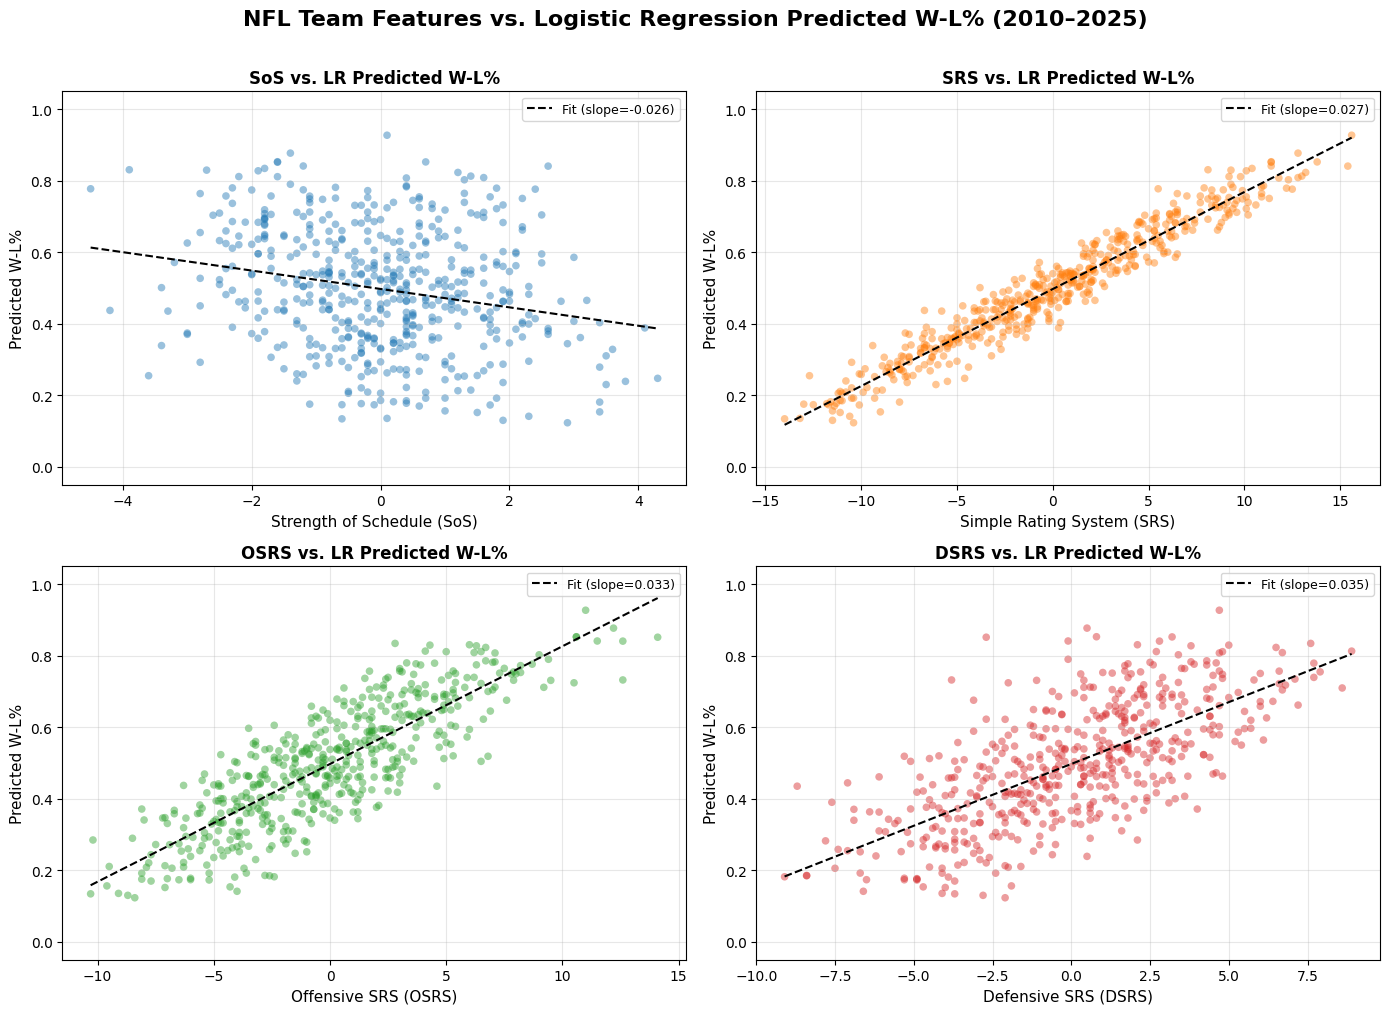

Scatterplot saved as feature_vs_lr_predicted_wlpct.png


In [10]:
# ── Logistic Regression: Predicted W-L% vs. each feature (full dataset) ──
import matplotlib.pyplot as plt
import numpy as np

_all_features = _all_data[['SoS', 'SRS', 'OSRS', 'DSRS']].values
_lr_predicted_wlpct = model.predict(_all_features)

features = ['SoS', 'SRS', 'OSRS', 'DSRS']
feature_labels = [
    'Strength of Schedule (SoS)',
    'Simple Rating System (SRS)',
    'Offensive SRS (OSRS)',
    'Defensive SRS (DSRS)'
]
colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('NFL Team Features vs. Logistic Regression Predicted W-L% (2010–2025)', fontsize=16, fontweight='bold', y=1.01)

for ax, feat, label, color in zip(axes.flat, features, feature_labels, colors):
    x = _all_data[feat].values
    y = _lr_predicted_wlpct
    ax.scatter(x, y, alpha=0.45, s=30, color=color, edgecolors='none')
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle='--', label=f'Fit (slope={m:.3f})')
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Predicted W-L%', fontsize=11)
    ax.set_title(f'{feat} vs. LR Predicted W-L%', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig('feature_vs_lr_predicted_wlpct.png', dpi=150, bbox_inches='tight')
plt.show()
print('Scatterplot saved as feature_vs_lr_predicted_wlpct.png')


# Neural Network Model

## Dylan Shaffer

In [11]:
import os
import pickle
import numpy as np
import pandas as pd
from sklearn.model_selection import train_test_split
from tensorflow import keras
from tensorflow.keras import layers

TEAM = 0; WINS = 1; LOSSES = 2; TIES = 3; WIN_PERCENTAGE = 4
POINTS_FOR = 5; POINTS_AGAINST = 6; POINTS_DIFFERENTIAL = 7
MARGIN_OF_VICTORY = 8; STRENGTH_OF_SCHEDULE = 9
SIMPLE_RATING_SYSTEM = 10; OFFENSIVE_SRS = 11; DEFENSIVE_SRS = 12

DATA_FILEPATH = "Data"
MODEL_FILEPATH = "Models/Neural Network"
PREDICTIONS_FILEPATH = "Predictions/Neural Network"

DROP_COLS = ['W', 'L', 'T', 'W-L%', 'PF', 'PA', 'PD', 'MoV']

/Users/dylan/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


In [12]:
def read_data(NFL_YEAR, team_name):
    team_data = []
    with open(os.path.join(DATA_FILEPATH, f"{NFL_YEAR}.csv"), "r") as file:
        data = pd.read_csv(file)
        for index, row in data.iterrows():
            if row.iloc[TEAM] == team_name:
                team_data.append([
                    row.iloc[WINS], row.iloc[LOSSES], row.iloc[TIES], row.iloc[WIN_PERCENTAGE],
                    row.iloc[POINTS_FOR], row.iloc[POINTS_AGAINST], row.iloc[POINTS_DIFFERENTIAL],
                    row.iloc[MARGIN_OF_VICTORY], row.iloc[STRENGTH_OF_SCHEDULE],
                    row.iloc[SIMPLE_RATING_SYSTEM], row.iloc[OFFENSIVE_SRS], row.iloc[DEFENSIVE_SRS]
                ])
    return pd.DataFrame(team_data, columns=['W', 'L', 'T', 'W-L%', 'PF', 'PA', 'PD', 'MoV', 'SoS', 'SRS', 'OSRS', 'DSRS'])

In [13]:
def build_model(input_dim):
    model = keras.Sequential([
        layers.Dense(64, activation="relu", input_shape=(input_dim,)),
        layers.Dense(64, activation="relu"),
        layers.Dense(1)  # single output: W-L%
    ])
    model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
    return model

In [14]:
def train_model():
    mean = X_train_global.mean(axis=0)
    std = X_train_global.std(axis=0)

    X_train_norm = (X_train_global - mean) / std
    X_val_norm = (X_val_global - mean) / std

    model = build_model(X_train_norm.shape[1])

    early_stopping = keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=10,
        restore_best_weights=True,
        verbose=1
    )

    # log every 10 epochs so we can see where val_loss plateaus
    epoch_logger = keras.callbacks.LambdaCallback(
        on_epoch_end=lambda epoch, logs: print(
            f"  Epoch {epoch+1:3d} — loss: {logs['loss']:.6f}  val_loss: {logs['val_loss']:.6f}  val_mae: {logs['val_mae']:.6f}"
        ) if (epoch + 1) % 10 == 0 else None
    )

    print("Training (max 100 epochs, early stopping patience=10)...")
    history = model.fit(
        X_train_norm, y_train_global,
        epochs=100, batch_size=8, verbose=0,
        validation_data=(X_val_norm, y_val_global),
        callbacks=[early_stopping, epoch_logger]
    )

    stopped_epoch = early_stopping.stopped_epoch
    best_epoch = stopped_epoch - early_stopping.patience + 1 if stopped_epoch > 0 else len(history.history["val_loss"])
    best_val_loss = min(history.history["val_loss"])
    print(f"\nDone. Best epoch: {best_epoch}, best val_loss: {best_val_loss:.6f}, total epochs: {len(history.history['val_loss'])}")

    return model, mean, std


In [15]:
def save_model(NFL_YEAR, model, mean, std):
    os.makedirs(MODEL_FILEPATH, exist_ok=True)
    model.save(os.path.join(MODEL_FILEPATH, f"nn_model_{NFL_YEAR}.keras"))
    np.save(os.path.join(MODEL_FILEPATH, f"nn_mean_{NFL_YEAR}.npy"), mean)
    np.save(os.path.join(MODEL_FILEPATH, f"nn_std_{NFL_YEAR}.npy"),  std)

In [16]:
def make_predictions(NFL_YEAR):
    model = keras.models.load_model(os.path.join(MODEL_FILEPATH, "nn_model_global.keras"))
    mean = np.load(os.path.join(MODEL_FILEPATH, "nn_mean_global.npy"))
    std = np.load(os.path.join(MODEL_FILEPATH, "nn_std_global.npy"))

    schedule_df = pd.read_csv(os.path.join("Schedule", f"{NFL_YEAR}.csv"))
    if schedule_df.empty:
        print(f"No schedule found for {NFL_YEAR}")
        return

    season_data = pd.read_csv(os.path.join(DATA_FILEPATH, f"{NFL_YEAR}.csv"))
    team_stats  = {row.iloc[TEAM]: read_data(NFL_YEAR, row.iloc[TEAM]) for _, row in season_data.iterrows()}
    team_stats  = {k: v for k, v in team_stats.items() if v is not None and len(v) > 0}

    team_wins  = {team: 0 for team in NFL_TEAMS}
    team_games = {team: 0 for team in NFL_TEAMS}

    for _, row in schedule_df.iterrows():
        winner, loser = row['Winner/tie'], row['Loser/tie']
        if winner not in team_stats or loser not in team_stats:
            continue

        def predict_team(team):
            X = team_stats[team].drop(columns=DROP_COLS).values
            X = (X - mean) / std
            return model.predict(X, verbose=0)[0][0]

        winner_pred = predict_team(winner)
        loser_pred  = predict_team(loser)

        predicted_winner = winner if winner_pred > loser_pred else loser
        predicted_loser  = loser  if winner_pred > loser_pred else winner
        team_wins[predicted_winner]  += 1
        team_games[predicted_winner] += 1
        team_games[predicted_loser]  += 1

    predictions = [
        [team,
         team_stats[team]['W-L%'].iloc[0] if team in team_stats else 0.0,
         team_wins[team] / team_games[team] if team_games[team] > 0 else 0.0]
        for team in NFL_TEAMS
    ]
    predictions_df = pd.DataFrame(predictions, columns=['Team', 'Actual W-L%', 'Predicted W-L%'])
    os.makedirs(PREDICTIONS_FILEPATH, exist_ok=True)
    predictions_df.to_csv(os.path.join(PREDICTIONS_FILEPATH, f"predictions_{NFL_YEAR}.csv"), index=False)
    return predictions_df

In [17]:
model, mean, std = train_model()
save_model("global", model, mean, std)
print("Model saved.")

# Run game-by-game predictions for each year using the global model
for year in NFL_YEARS:
    print(f"\nPredicting for {year}...")
print(f"\nPredictions for 2025:")
preds = make_predictions(2025)
display(preds)


/Users/dylan/Library/Python/3.9/lib/python/site-packages/keras/src/layers/core/dense.py:93: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Training (max 100 epochs, early stopping patience=10)...
  Epoch  10 — loss: 0.007669  val_loss: 0.013914  val_mae: 0.099618
Epoch 18: early stopping
Restoring model weights from the end of the best epoch: 8.

Done. Best epoch: 8, best val_loss: 0.008281, total epochs: 18
Model saved.

Predicting for 2010...

Predicting for 2011...

Predicting for 2012...

Predicting for 2013...

Predicting for 2014...

Predicting for 2015...

Predicting for 2016...

Predicting for 2017...

Predicting for 2018...

Predicting for 2019...

Predicting for 2020...

Predicting for 2021...

Predicting for 2022...

Predicting for 2023...

Predicting for 2024...

Predicting for 2025...

Predictions for 2025:


,Team,Actual W-L%,Predicted W-L%
0,Arizona Cardinals,0.176,0.058824
1,Atlanta Falcons,0.471,0.470588
2,Baltimore Ravens,0.471,0.647059
3,Buffalo Bills,0.706,0.823529
4,Carolina Panthers,0.471,0.235294
5,Chicago Bears,0.647,0.764706
6,Cincinnati Bengals,0.353,0.235294
7,Cleveland Browns,0.294,0.176471
8,Dallas Cowboys,0.441,0.470588
9,Denver Broncos,0.824,0.823529


In [18]:
from sklearn.metrics import r2_score, mean_squared_error

# Normalize test set with the same stats used during training
X_test_norm = (X_test_global - mean) / std

# Raw predictions from the neural network
y_pred_nn = model.predict(X_test_norm, verbose=0).flatten()

r2  = r2_score(y_test_global, y_pred_nn)
mse = mean_squared_error(y_test_global, y_pred_nn)

# Percent error per sample (avoid divide-by-zero for 0.0 actual values)
with np.errstate(divide='ignore', invalid='ignore'):
    pct_err = np.where(
        y_test_global != 0,
        np.abs((y_test_global - y_pred_nn) / y_test_global) * 100,
        np.nan
    )
mean_pct_err = np.nanmean(pct_err)

print(f"R²: {r2:.4f}")
print(f"MSE: {mse:.6f}")
print(f"Mean % Error: {mean_pct_err:.2f} %")


R²: 0.8159
MSE: 0.007187
Mean % Error: 16.66 %


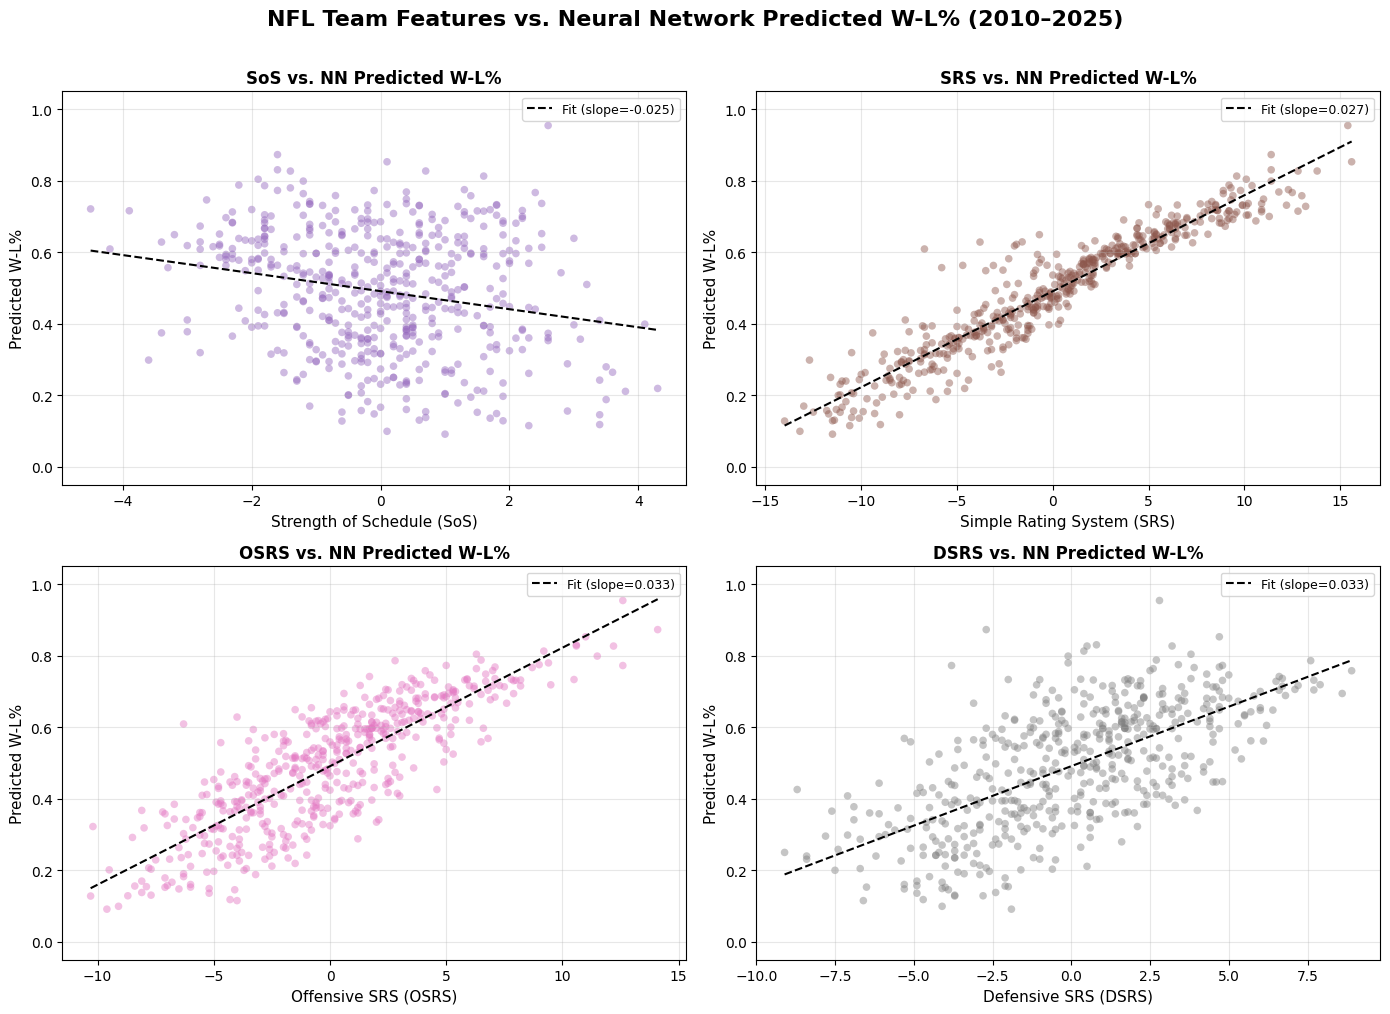

Scatterplot saved as feature_vs_nn_predicted_wlpct.png


In [19]:
# ── Neural Network: Predicted W-L% vs. each feature (full dataset) ──
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Predict W-L% for every sample using the trained NN
_all_features = _all_data[['SoS', 'SRS', 'OSRS', 'DSRS']].values
_all_features_norm = (_all_features - mean) / std
_nn_predicted_wlpct = model.predict(_all_features_norm, verbose=0).flatten()

features = ['SoS', 'SRS', 'OSRS', 'DSRS']
feature_labels = [
    'Strength of Schedule (SoS)',
    'Simple Rating System (SRS)',
    'Offensive SRS (OSRS)',
    'Defensive SRS (DSRS)'
]
colors = ['#9467bd', '#8c564b', '#e377c2', '#7f7f7f']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('NFL Team Features vs. Neural Network Predicted W-L% (2010–2025)', fontsize=16, fontweight='bold', y=1.01)

for ax, feat, label, color in zip(axes.flat, features, feature_labels, colors):
    x = _all_data[feat].values
    y = _nn_predicted_wlpct
    ax.scatter(x, y, alpha=0.45, s=30, color=color, edgecolors='none')

    # Best-fit line
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle='--', label=f'Fit (slope={m:.3f})')

    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Predicted W-L%', fontsize=11)
    ax.set_title(f'{feat} vs. NN Predicted W-L%', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig('feature_vs_nn_predicted_wlpct.png', dpi=150, bbox_inches='tight')
plt.show()
print('Scatterplot saved as feature_vs_nn_predicted_wlpct.png')


# Random Forest Model

## Simon Liedtke

In [20]:
import os
import pickle
import numpy as np
import pandas as pd
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import RandomizedSearchCV
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error

RF_MODEL_FILEPATH = "Models/Random Forest"
RF_PREDICTIONS_FILEPATH = "Predictions/Random Forest"

SCHEDULE_FILEPATH = "Schedule"
DATA_FILEPATH = "Data"

TEAM = 0; WINS = 1; LOSSES = 2; TIES = 3; WIN_PERCENTAGE = 4
POINTS_FOR = 5; POINTS_AGAINST = 6; POINTS_DIFFERENTIAL = 7
MARGIN_OF_VICTORY = 8; STRENGTH_OF_SCHEDULE = 9
SIMPLE_RATING_SYSTEM = 10; OFFENSIVE_SRS = 11; DEFENSIVE_SRS = 12

NFL_TEAMS = ['Arizona Cardinals', 'Atlanta Falcons', 'Baltimore Ravens', 'Buffalo Bills',
             'Carolina Panthers', 'Chicago Bears', 'Cincinnati Bengals', 'Cleveland Browns',
             'Dallas Cowboys', 'Denver Broncos', 'Detroit Lions', 'Green Bay Packers',
             'Houston Texans', 'Indianapolis Colts', 'Jacksonville Jaguars', 'Kansas City Chiefs',
             'Las Vegas Raiders', 'Los Angeles Chargers', 'Los Angeles Rams', 'Miami Dolphins',
             'Minnesota Vikings', 'New England Patriots', 'New Orleans Saints', 'New York Giants',
             'New York Jets', 'Philadelphia Eagles', 'Pittsburgh Steelers', 'San Francisco 49ers',
             'Seattle Seahawks', 'Tampa Bay Buccaneers', 'Tennessee Titans', 'Washington Commanders']
NFL_YEARS = [str(year) for year in range(2010, 2026)]
DROP_COLS = ['W', 'L', 'T', 'W-L%', 'PF', 'PA', 'PD', 'MoV']


In [21]:
def read_data(NFL_YEAR, team_name):
    team_data = []
    with open(os.path.join(DATA_FILEPATH, f"{NFL_YEAR}.csv"), "r") as file:
        data = pd.read_csv(file)
        for index, row in data.iterrows():
            if row.iloc[TEAM] == team_name:
                team_data.append([
                    row.iloc[WINS], row.iloc[LOSSES], row.iloc[TIES], row.iloc[WIN_PERCENTAGE],
                    row.iloc[POINTS_FOR], row.iloc[POINTS_AGAINST], row.iloc[POINTS_DIFFERENTIAL],
                    row.iloc[MARGIN_OF_VICTORY], row.iloc[STRENGTH_OF_SCHEDULE],
                    row.iloc[SIMPLE_RATING_SYSTEM], row.iloc[OFFENSIVE_SRS], row.iloc[DEFENSIVE_SRS]
                ])
    return pd.DataFrame(team_data, columns=['W', 'L', 'T', 'W-L%', 'PF', 'PA', 'PD', 'MoV', 'SoS', 'SRS', 'OSRS', 'DSRS'])


In [22]:
def train_model():
    param_grid = {
        'n_estimators':      [5000],
        'max_depth':         [None, 2, 20],
        'min_samples_split': [2, 20],
        'min_samples_leaf':  [2, 20],
        'bootstrap':         [True, False],
    }
    random_search = RandomizedSearchCV(
        RandomForestRegressor(random_state=42),
        param_grid,
        n_iter=10,
        cv=3,
        random_state=42,
        n_jobs=-1
    )
    random_search.fit(X_train_global, y_train_global)
    print("Best hyperparameters:", random_search.best_params_)
    return random_search.best_estimator_


In [23]:
def save_model(NFL_YEAR, model):
    os.makedirs(RF_MODEL_FILEPATH, exist_ok=True)
    with open(os.path.join(RF_MODEL_FILEPATH, f"rf_model_{NFL_YEAR}.pkl"), "wb") as f:
        pickle.dump(model, f)


In [24]:
def make_predictions(NFL_YEAR):
    model_path = os.path.join(RF_MODEL_FILEPATH, "rf_model_global.pkl")
    with open(model_path, "rb") as f:
        model = pickle.load(f)

    schedule_df = pd.read_csv(os.path.join(SCHEDULE_FILEPATH, f"{NFL_YEAR}.csv"))
    if schedule_df.empty:
        print(f"No schedule found for {NFL_YEAR}")
        return

    try:
        season_data = pd.read_csv(os.path.join(DATA_FILEPATH, f"{NFL_YEAR}.csv"))
        team_stats  = {row.iloc[TEAM]: read_data(NFL_YEAR, row.iloc[TEAM])
                       for _, row in season_data.iterrows()}
        team_stats  = {k: v for k, v in team_stats.items() if v is not None and len(v) > 0}
    except FileNotFoundError:
        print(f"Data file for {NFL_YEAR} not found")
        return

    team_wins  = {team: 0 for team in NFL_TEAMS}
    team_games = {team: 0 for team in NFL_TEAMS}

    for _, row in schedule_df.iterrows():
        winner, loser = row['Winner/tie'], row['Loser/tie']
        if winner not in team_stats or loser not in team_stats:
            continue
        winner_pred = model.predict(team_stats[winner].drop(columns=DROP_COLS).values)[0]
        loser_pred  = model.predict(team_stats[loser].drop(columns=DROP_COLS).values)[0]
        predicted_winner = winner if winner_pred > loser_pred else loser
        predicted_loser  = loser  if winner_pred > loser_pred else winner
        team_wins[predicted_winner]  += 1
        team_games[predicted_winner] += 1
        team_games[predicted_loser]  += 1

    predictions = [
        [team,
         team_stats[team]['W-L%'].iloc[0] if team in team_stats else 0.0,
         team_wins[team] / team_games[team] if team_games[team] > 0 else 0.0]
        for team in NFL_TEAMS
    ]
    predictions_df = pd.DataFrame(predictions, columns=['Team', 'Actual W-L%', 'Predicted W-L%'])
    os.makedirs(RF_PREDICTIONS_FILEPATH, exist_ok=True)
    predictions_df.to_csv(os.path.join(RF_PREDICTIONS_FILEPATH, f"predictions_{NFL_YEAR}.csv"), index=False)
    return predictions_df


In [25]:
rf_model = train_model()
save_model("global", rf_model)
print("Model saved.")

# Evaluate on the global validation split
y_pred_rf_val = rf_model.predict(X_val_global)
print(f"R²:  {r2_score(y_val_global,  y_pred_rf_val):.4f}")
print(f"MSE: {mean_squared_error(y_val_global, y_pred_rf_val):.6f}")

# Run game-by-game predictions for each year using the global model
for year in NFL_YEARS:
    print(f"\nPredicting for {year}...")
print(f"\nPredictions for 2025:")
preds = make_predictions(2025)
display(preds)


Best hyperparameters: {'n_estimators': 5000, 'min_samples_split': 20, 'min_samples_leaf': 2, 'max_depth': 20, 'bootstrap': True}
Model saved.
R²:  0.8190
MSE: 0.006972

Predicting for 2010...

Predicting for 2011...

Predicting for 2012...

Predicting for 2013...

Predicting for 2014...

Predicting for 2015...

Predicting for 2016...

Predicting for 2017...

Predicting for 2018...

Predicting for 2019...

Predicting for 2020...

Predicting for 2021...

Predicting for 2022...

Predicting for 2023...

Predicting for 2024...

Predicting for 2025...

Predictions for 2025:


,Team,Actual W-L%,Predicted W-L%
0,Arizona Cardinals,0.176,0.058824
1,Atlanta Falcons,0.471,0.470588
2,Baltimore Ravens,0.471,0.588235
3,Buffalo Bills,0.706,0.823529
4,Carolina Panthers,0.471,0.352941
5,Chicago Bears,0.647,0.764706
6,Cincinnati Bengals,0.353,0.235294
7,Cleveland Browns,0.294,0.176471
8,Dallas Cowboys,0.441,0.294118
9,Denver Broncos,0.824,0.941176


In [26]:
# Evaluate on the global test split (held out until final evaluation)
y_pred_rf_test = rf_model.predict(X_test_global)

mse = mean_squared_error(y_test_global, y_pred_rf_test)
r2  = r2_score(y_test_global, y_pred_rf_test)
mae = mean_absolute_error(y_test_global, y_pred_rf_test)

# Percent error per sample
with np.errstate(divide='ignore', invalid='ignore'):
    pct_err = np.where(
        y_test_global != 0,
        np.abs((y_test_global - y_pred_rf_test) / y_test_global) * 100,
        np.nan
    )
mean_pct_err = np.nanmean(pct_err)

print("Random Forest — Test-Set Performance (global 20% hold-out)")
print(f"  R²            : {r2:.4f}")
print(f"  MSE           : {mse:.6f}")
print(f"  MAE           : {mae:.6f}")
print(f"  Mean % Error  : {mean_pct_err:.2f} %")


Random Forest — Test-Set Performance (global 20% hold-out)
  R²            : 0.8079
  MSE           : 0.007503
  MAE           : 0.072901
  Mean % Error  : 19.17 %


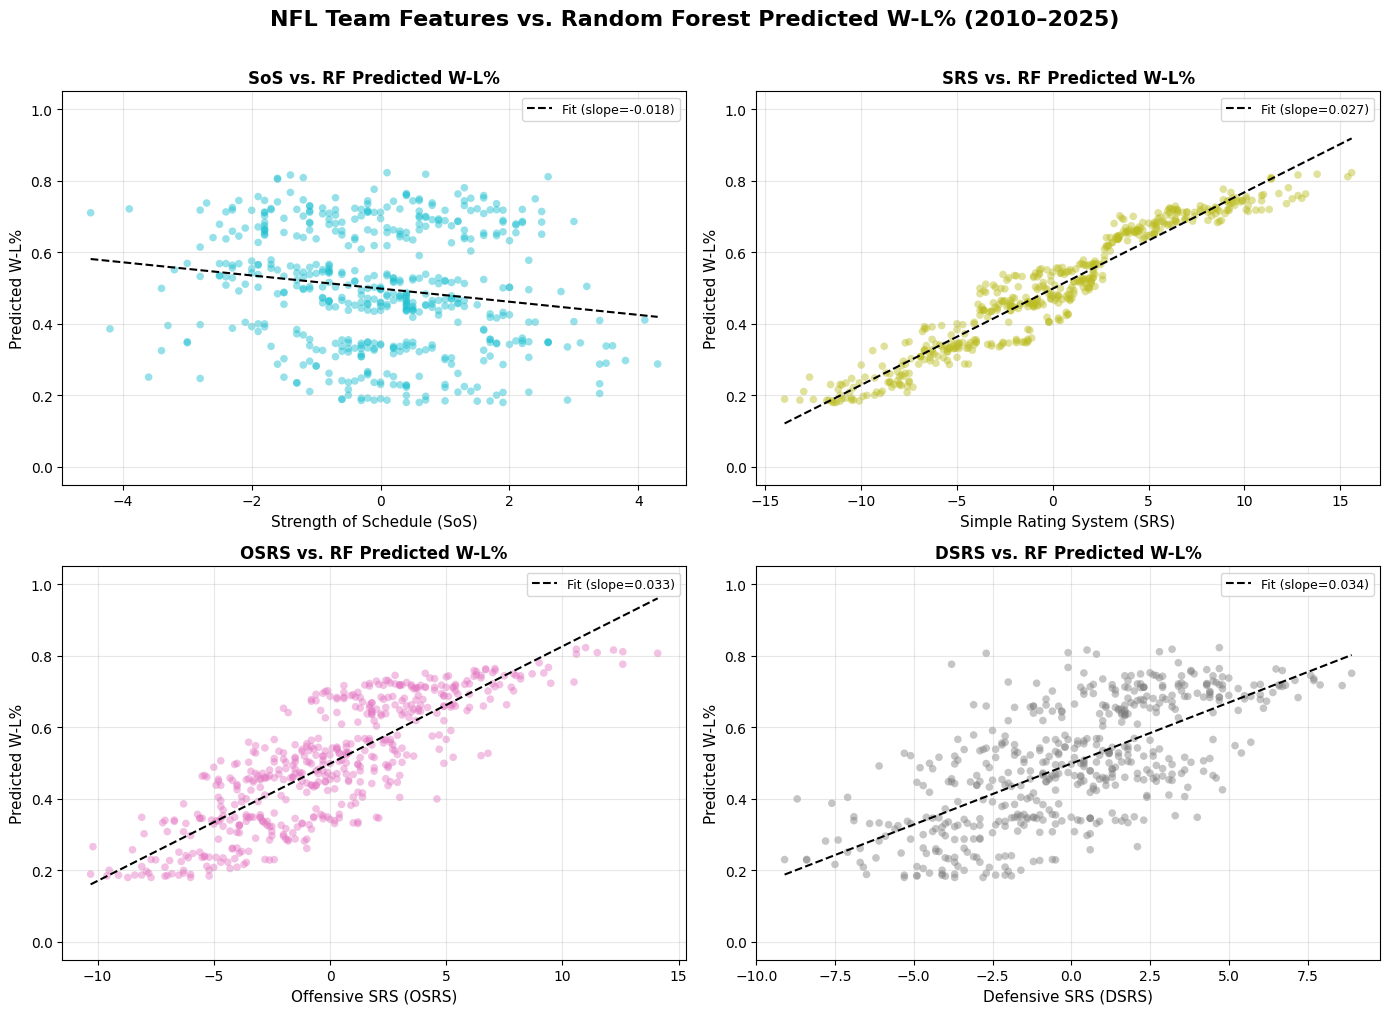

Scatterplot saved as feature_vs_rf_predicted_wlpct.png


In [27]:
# ── Random Forest: Predicted W-L% vs. each feature (full dataset) ──
import matplotlib.pyplot as plt
import numpy as np

_all_features = _all_data[['SoS', 'SRS', 'OSRS', 'DSRS']].values
_rf_predicted_wlpct = rf_model.predict(_all_features)

features = ['SoS', 'SRS', 'OSRS', 'DSRS']
feature_labels = [
    'Strength of Schedule (SoS)',
    'Simple Rating System (SRS)',
    'Offensive SRS (OSRS)',
    'Defensive SRS (DSRS)'
]
colors = ['#17becf', '#bcbd22', '#e377c2', '#7f7f7f']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('NFL Team Features vs. Random Forest Predicted W-L% (2010–2025)', fontsize=16, fontweight='bold', y=1.01)

for ax, feat, label, color in zip(axes.flat, features, feature_labels, colors):
    x = _all_data[feat].values
    y = _rf_predicted_wlpct
    ax.scatter(x, y, alpha=0.45, s=30, color=color, edgecolors='none')
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle='--', label=f'Fit (slope={m:.3f})')
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Predicted W-L%', fontsize=11)
    ax.set_title(f'{feat} vs. RF Predicted W-L%', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig('feature_vs_rf_predicted_wlpct.png', dpi=150, bbox_inches='tight')
plt.show()
print('Scatterplot saved as feature_vs_rf_predicted_wlpct.png')


# Naive Bayes Model

## Dilen Patel

In [28]:
import os
import joblib
import numpy as np
import pandas as pd
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    mean_squared_error,
    r2_score,
)

NB_MODEL_FILEPATH       = "Models/Naive Bayes"
NB_PREDICTIONS_FILEPATH = "Predictions/Naive Bayes"


In [29]:
def wl_bucket_label(wlp):
    """Convert W-L% into one of 4 bucket classes."""
    if wlp < 0.250:
        return 0  # Very Poor
    elif wlp < 0.500:
        return 1  # Below Average
    elif wlp < 0.750:
        return 2  # Good
    else:
        return 3  # Elite


def bucket_name(bucket_id):
    return {0: "Very Poor", 1: "Below Average", 2: "Good", 3: "Elite"}.get(bucket_id, "Unknown")


def bucket_midpoint(bucket_id):
    """Return the midpoint W-L% for a given bucket (used as the numeric prediction)."""
    return {0: 0.125, 1: 0.375, 2: 0.625, 3: 0.875}.get(bucket_id, 0.0)


In [30]:
_nb_data = _all_data.copy()
_nb_data["WL_bucket"] = _nb_data["W-L%"].apply(wl_bucket_label)

NB_FEATURE_COLS = ["SoS", "SRS", "OSRS", "DSRS"]

_nb_y_all = _nb_data["WL_bucket"].values
_nb_X_all = _nb_data[NB_FEATURE_COLS].values

from sklearn.model_selection import train_test_split

X_nb_train, _nb_X_temp, y_nb_train, _nb_y_temp = train_test_split(
    _nb_X_all, _nb_y_all, test_size=0.40, random_state=42
)
X_nb_val, X_nb_test, y_nb_val, y_nb_test = train_test_split(
    _nb_X_temp, _nb_y_temp, test_size=0.50, random_state=42
)

# keep actual W-L% values aligned for regression metrics later
_nb_wlp_all = _nb_data["W-L%"].values
_, _wlp_temp, _, _ = train_test_split(
    _nb_wlp_all, _nb_y_all, test_size=0.40, random_state=42
)
_, wlp_nb_test, _, _ = train_test_split(
    _wlp_temp, _nb_y_temp, test_size=0.50, random_state=42
)

print(f"NB features : {NB_FEATURE_COLS}")
print(f"Train (60%) : {len(X_nb_train)}")
print(f"Val   (20%) : {len(X_nb_val)}")
print(f"Test  (20%) : {len(X_nb_test)}")


NB features : ['SoS', 'SRS', 'OSRS', 'DSRS']
Train (60%) : 307
Val   (20%) : 102
Test  (20%) : 103


In [31]:
def train_model():
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_nb_train)
    model = GaussianNB()
    model.fit(X_train_scaled, y_nb_train)
    return model, scaler


def save_model(model, scaler):
    os.makedirs(NB_MODEL_FILEPATH, exist_ok=True)
    joblib.dump(model,  os.path.join(NB_MODEL_FILEPATH, "nb_wlp_bucket.pkl"))
    joblib.dump(scaler, os.path.join(NB_MODEL_FILEPATH, "scaler_wlp_bucket.pkl"))


def evaluate_model(model, scaler):
    X_test_scaled = scaler.transform(X_nb_test)
    preds = model.predict(X_test_scaled)

    acc = accuracy_score(y_nb_test, preds)
    report = classification_report(
        y_nb_test, preds,
        target_names=["Very Poor", "Below Average", "Good", "Elite"],
        zero_division=0,
    )
    cm = confusion_matrix(y_nb_test, preds)

    predicted_wlp = np.array([bucket_midpoint(int(p)) for p in preds])
    actual_wlp = wlp_nb_test.astype(float)

    mse = mean_squared_error(actual_wlp, predicted_wlp)
    r2 = r2_score(actual_wlp, predicted_wlp)

    with np.errstate(divide='ignore', invalid='ignore'):
        pct_errors = np.where(
            actual_wlp != 0,
            np.abs((actual_wlp - predicted_wlp) / actual_wlp) * 100,
            np.nan,
        )
    mean_pct_err = np.nanmean(pct_errors)

    print("Naive Bayes - Test Set Performance")
    print(f"  Accuracy     : {acc:.4f}")
    print(f"  MSE (W-L%)   : {mse:.6f}")
    print(f"  R² (W-L%)    : {r2:.6f}")
    print(f"  Mean % Error : {mean_pct_err:.2f}%")
    print()
    print("Classification Report")
    print("-" * 40)
    print(report)
    print("Confusion Matrix")
    print("-" * 40)
    print(cm)

    pred_rows = []
    for i in range(len(y_nb_test)):
        actual_bucket = int(y_nb_test[i])
        pred_bucket = int(preds[i])
        actual_wl_val = float(actual_wlp[i])
        pred_wl_val = float(predicted_wlp[i])
        abs_err = abs(actual_wl_val - pred_wl_val)
        pct_err = float(pct_errors[i]) if not np.isnan(pct_errors[i]) else None
        pred_rows.append({
            "Actual_WL_Percent"   : round(actual_wl_val, 3),
            "Predicted_WL_Percent": round(pred_wl_val, 3),
            "Absolute_Error"      : round(abs_err, 3),
            "Percent_Error"       : round(pct_err, 2) if pct_err is not None else None,
            "Actual_Bucket"       : bucket_name(actual_bucket),
            "Predicted_Bucket"    : bucket_name(pred_bucket),
            "Correct"             : int(actual_bucket == pred_bucket),
        })
    return pd.DataFrame(pred_rows)


def save_predictions(preds_df):
    os.makedirs(NB_PREDICTIONS_FILEPATH, exist_ok=True)
    preds_df.to_csv(
        os.path.join(NB_PREDICTIONS_FILEPATH, "predictions.csv"), index=False
    )


In [32]:
nb_model, nb_scaler = train_model()
save_model(nb_model, nb_scaler)
print("Model saved.")

preds_df = evaluate_model(nb_model, nb_scaler)
save_predictions(preds_df)
print("\nPredictions saved.")
display(preds_df)


Model saved.
Naive Bayes - Test Set Performance
  Accuracy     : 0.7282
  MSE (W-L%)   : 0.012165
  R² (W-L%)    : 0.688459
  Mean % Error : 20.16%

Classification Report
----------------------------------------
               precision    recall  f1-score   support

    Very Poor       0.55      0.75      0.63         8
Below Average       0.71      0.73      0.72        37
         Good       0.75      0.73      0.74        41
        Elite       0.86      0.71      0.77        17

     accuracy                           0.73       103
    macro avg       0.72      0.73      0.72       103
 weighted avg       0.74      0.73      0.73       103

Confusion Matrix
----------------------------------------
[[ 6  2  0  0]
 [ 5 27  5  0]
 [ 0  9 30  2]
 [ 0  0  5 12]]

Predictions saved.


,Actual_WL_Percent,Predicted_WL_Percent,Absolute_Error,Percent_Error,Actual_Bucket,Predicted_Bucket,Correct
0,0.750,0.625,0.125,16.67,Elite,Good,0
1,0.313,0.375,0.062,19.81,Below Average,Below Average,1
2,0.313,0.375,0.062,19.81,Below Average,Below Average,1
3,0.375,0.375,0.000,0.00,Below Average,Below Average,1
4,0.313,0.375,0.062,19.81,Below Average,Below Average,1
...,...,...,...,...,...,...,...
98,0.647,0.875,0.228,35.24,Good,Elite,0
99,0.588,0.375,0.213,36.22,Good,Below Average,0
100,0.531,0.375,0.156,29.38,Good,Below Average,0
101,0.750,0.625,0.125,16.67,Elite,Good,0


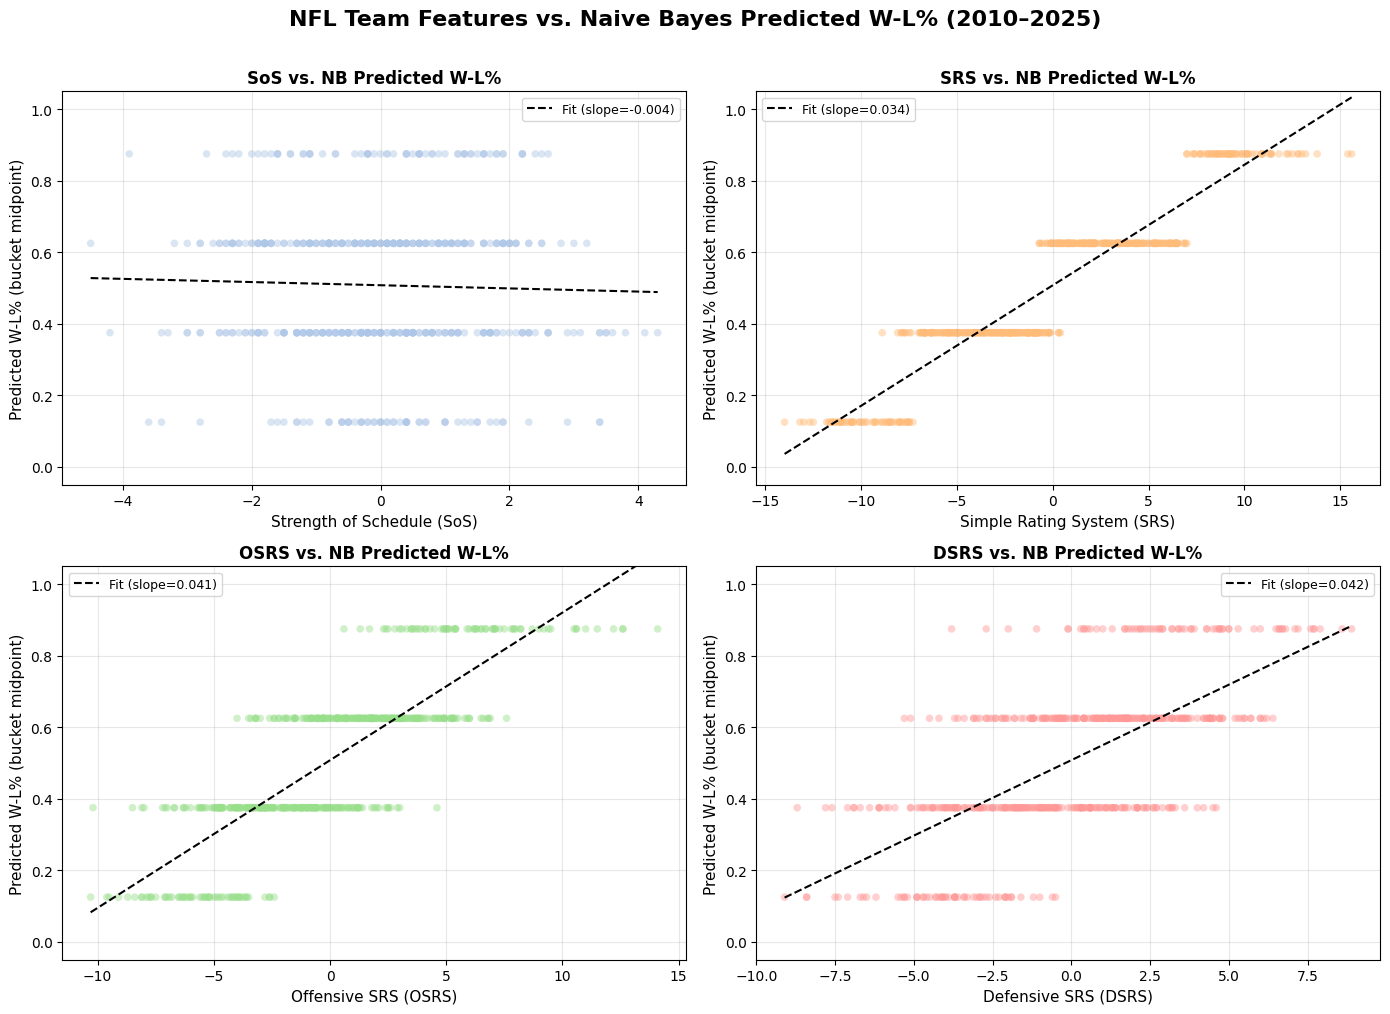

Scatterplot saved as feature_vs_nb_predicted_wlpct.png


In [33]:
# ── Naive Bayes: Predicted W-L% vs. each feature (full dataset) ──
import matplotlib.pyplot as plt
import numpy as np

_all_features_nb = _all_data[['SoS', 'SRS', 'OSRS', 'DSRS']].values
_all_features_nb_scaled = nb_scaler.transform(_all_features_nb)
_nb_bucket_preds = nb_model.predict(_all_features_nb_scaled)
_nb_predicted_wlpct = np.array([bucket_midpoint(int(p)) for p in _nb_bucket_preds])

features = ['SoS', 'SRS', 'OSRS', 'DSRS']
feature_labels = [
    'Strength of Schedule (SoS)',
    'Simple Rating System (SRS)',
    'Offensive SRS (OSRS)',
    'Defensive SRS (DSRS)'
]
colors = ['#aec7e8', '#ffbb78', '#98df8a', '#ff9896']

fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('NFL Team Features vs. Naive Bayes Predicted W-L% (2010–2025)', fontsize=16, fontweight='bold', y=1.01)

for ax, feat, label, color in zip(axes.flat, features, feature_labels, colors):
    x = _all_data[feat].values
    y = _nb_predicted_wlpct
    ax.scatter(x, y, alpha=0.45, s=30, color=color, edgecolors='none')
    m, b = np.polyfit(x, y, 1)
    x_line = np.linspace(x.min(), x.max(), 200)
    ax.plot(x_line, m * x_line + b, color='black', linewidth=1.5, linestyle='--', label=f'Fit (slope={m:.3f})')
    ax.set_xlabel(label, fontsize=11)
    ax.set_ylabel('Predicted W-L% (bucket midpoint)', fontsize=11)
    ax.set_title(f'{feat} vs. NB Predicted W-L%', fontsize=12, fontweight='bold')
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
    ax.set_ylim(-0.05, 1.05)

plt.tight_layout()
plt.savefig('feature_vs_nb_predicted_wlpct.png', dpi=150, bbox_inches='tight')
plt.show()
print('Scatterplot saved as feature_vs_nb_predicted_wlpct.png')
